# Analyse Mojito samples

In [1]:
source_index = 7

In [2]:
thin_samples = False

In [3]:
from dotenv import load_dotenv
import os
# Load variables from the .env file
load_dotenv()
my_password = os.getenv("LISA_CONSORTIUM_KEY")
my_username = os.getenv("LISA_CONSORTIUM_NAME")

In [4]:
from mojito.download import get_source_params

# Get source parameters for emri brick
params = get_source_params("emri", source_id=source_index, username=my_username, token=my_password)

/data/leuven/367/vsc36785/miniconda3/envs/lisatools_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING! Publications using Mojito data are currently not allowed! Please keep in touch, as publication policies will soon be published.


In [5]:
import numpy as np
from eryn.backends import HDFBackend as eryn_HDF_Backend
import matplotlib.pyplot as plt
import corner
import os
import pandas as pd
import warnings
import matplotlib.lines as mlines
from matplotlib.font_manager import FontProperties
plt.rcParams['font.size'] = 20

source_dir = f"{os.getcwd()}/output/source_{source_index}"

In [6]:
def analyse_samples(file_path, discard = 0):
    reader = eryn_HDF_Backend(file_path,read_only = True)

    N_iterations = reader.get_chain()['model_0'].shape[0]
    N_temps = reader.get_chain()['model_0'].shape[1]
    N_walkers = reader.get_chain()['model_0'].shape[2]
    N_params = reader.get_chain()['model_0'].shape[-1]

    samples_after_burnin = [reader.get_chain(discard = discard)['model_0'][:,i].reshape(-1,N_params) 
                        for i in range(N_temps)]  # Take true chain]


    log_like = reader.get_log_like(discard = discard)
    plt.plot(log_like[:,0,:]);
    plt.xlabel(r'Iteration')
    plt.ylabel(r'Log likelihood')
    plt.show()
    return samples_after_burnin, reader, log_like, N_params,

def corner_plot(burned_samples, true_params, param_labels, corner_kwargs, title = r'Corner plot', plot_name = None):

    N_params = len(param_labels)
    true_params = true_params[0:N_params]
    trunc_samples = burned_samples[0][:,:N_params]
    print(trunc_samples.shape)
    
    samples_corner = np.column_stack(trunc_samples)

    figure = corner.corner(trunc_samples,bins = 30, color = 'blue', alpha=0.7, **corner_kwargs)

    
    axes = np.array(figure.axes).reshape((N_params, N_params))

    for i in range(N_params):
        ax = axes[i, i]
        ax.axvline(true_params[i], color="k")

    for yi in range(N_params):
        for xi in range(yi):
            ax = axes[yi, xi]
            ax.axhline(true_params[yi], color="k")
            ax.axvline(true_params[xi],color= "k")
            ax.plot(true_params[xi], true_params[yi], "sk")

    for ax in figure.get_axes():
        ax.tick_params(axis='both', labelsize=18)

    blue_line = mlines.Line2D([], [], color='blue', alpha=0.7, label=r'Posterior Distributions')
    black_line = mlines.Line2D([], [], color='black', label='True Value')

    # plt.legend(handles=[blue_line,black_line], fontsize = 65, frameon = True, bbox_to_anchor=(0.25, N_params), loc="upper right", title = title, title_fontproperties = FontProperties(size = , weight = 'bold'))
    # plt.subplots_adjust(left=-0.1, bottom=-0.1, right=None, top=None, wspace=0.15, hspace=0.15)
    if plot_name:
        plt.savefig(plot_name, bbox_inches = "tight")
    return figure



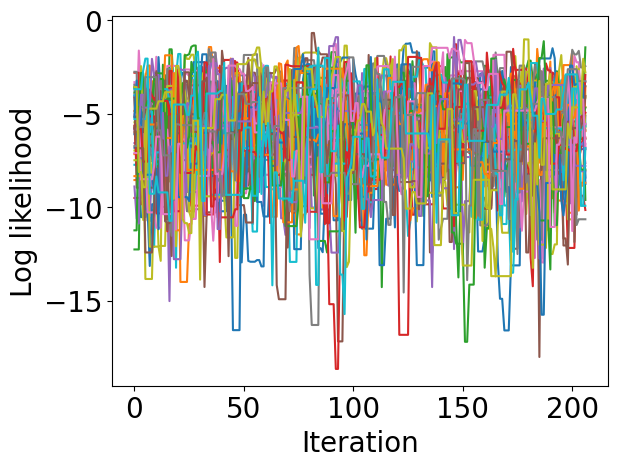

In [7]:
file_path = f"{source_dir}/PE_run_source_{source_index}.h5"

samples_after_burnin, reader, log_like, N_params = analyse_samples(file_path, discard = 300)

In [8]:
# Make nested list an array
samples_after_burnin = np.array(samples_after_burnin)
print(type(samples_after_burnin))
print(samples_after_burnin.shape)

# Check whether each walker samples a constant value.
print(np.all(samples_after_burnin[:, :] == samples_after_burnin[0, :], axis=0))

<class 'numpy.ndarray'>
(1, 8280, 12)
[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]


In [ ]:
def icrs_to_ecliptic(ra, dec):
    """Convert ICRS coordinates (ra, dec) to ecliptic coordinates (lambda, beta)."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    icrs_coord = SkyCoord(ra=ra * u.rad, dec=dec * u.rad, frame='icrs')
    ecliptic_coord = icrs_coord.barycentrictrueecliptic

    lambda_ecl = ecliptic_coord.lon.rad
    beta_ecl = ecliptic_coord.lat.rad

    return lambda_ecl, beta_ecl

ra = params['RightAscension']
dec = params['Declination']

lam_ecl, beta_ecl = icrs_to_ecliptic(ra, dec)
qS_ecl = np.pi / 2 - beta_ecl
phiS_ecl = lam_ecl

In [ ]:
# cut samples with auto-correlation time
tau = reader.get_autocorr_time(discard=300)['model_0'][0]
print(tau)

In [ ]:
# thin samples by autocorrelation time
samples_after_burnin.shape

In [ ]:
def thin_samples_with_tau(samples, tau):
    thinning_factor = int(max(tau))
    
    return samples[:, ::thinning_factor, :]

In [ ]:
thinned_samples = thin_samples_with_tau(samples_after_burnin, tau)
thinned_samples.shape

In [ ]:
plot_name = f'{source_dir}/corner_intrinsic_params_source_{source_index}'

params_label =[r"$M/M_{\odot}$", r"$\mu/M_{\odot}$", r"$a$", 
                     r"$p_{0}$", r"$e_{0}$", r"$D_{s}/Gpc$", 
                     r"$\theta_{S}$", r"$\phi_{S}$", r"$\theta_{K}$", r"$\phi_{K}$", 
                     r"$\Phi_{\phi_{0}}$", r"$\Phi_{r_{0}}$"] 

# params_label =[r"$M/M_{\odot}$", r"$\mu/M_{\odot}$", r"$a$", 
#                      r"$p_{0}$", r"$e_{0}$"] 

true_vals = np.array([
    params['PrimaryMassSSBFrame'],
    params['SecondaryMassSSBFrame'],
    params['PrimarySpinParameter'], #* np.sign(np.cos(params['InclinationAngle'])),
    params['SemiLatusRectum'],
    params['Eccentricity'],
    # np.cos(params['InclinationAngle']),
    params['LuminosityDistance']*1e-3,
    qS_ecl,  # np.pi/2 - beta
    phiS_ecl,  # lambda
    params['PolarAnglePrimarySpin'],
    params['AzimuthalAnglePrimarySpin'],
    params['AzimuthalPhase'],
    # params['PolarPhase'],
    params['RadialPhase'],
])

corner_kwargs = dict(plot_datapoints=False,
                     smooth1d=True,
                     labels=params_label, 
                     levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)), 
                     label_kwargs=dict(fontsize=40), 
                     max_n_ticks=4,
                     show_titles=False, 
                     smooth = True, 
                     labelpad = 0.4, 
                    )



# varying_cols = np.std(samples_after_burnin, axis=0) > 1e-10
# truncated_samples = samples_after_burnin[:, varying_cols]

# corner_kwargs["range"] = [(min(col), max(col)) for col in truncated_samples.T]
if thin_samples:
    samples = thinned_samples
else:
    samples = samples_after_burnin
figure = corner_plot(samples, 
                     true_vals, params_label, 
                     corner_kwargs, 
                     plot_name = plot_name)

Note: thinning the samples based on autocorrelation time as given by Eryn rapidly reduces the number of samples by a factor of 50. For proper inference studiues, this is necessary. For PE studies testing the waveform model, it is not. For the latter we aim to study the waveform generator at many different points. 